# USGS dataretrieval Python Package Groundwater-Level `get_field_measurements()` Examples

This notebook provides examples of using the Python dataretrieval package to retrieve groundwater level field measurements for a United States Geological Survey (USGS) monitoring location. The dataretrieval package provides a collection of functions to get data from the USGS Water Data API and other online sources of hydrology and water quality data.

### Install the Package

Use the following code to install the package if it doesn't exist already within your Jupyter Python environment.

In [1]:
!pip install dataretrieval

Load the package so you can use it along with other packages used in this notebook.

In [2]:
from IPython.display import display

import dataretrieval.waterdata as waterdata

### Basic Usage

The dataretrieval package has several functions that allow you to retrieve data from different services of the USGS Water Data API. This example uses the `get_field_measurements()` function to retrieve groundwater level field measurements. Field measurements are physically measured values collected during a visit to a monitoring location and are commonly used to record groundwater levels. The following arguments are commonly used:

* **monitoring_location_id** (string or list of strings): A unique identifier representing one or more monitoring locations. IDs combine the responsible agency code with the location number, separated by a hyphen (e.g. `USGS-434400121275801`).
* **parameter_code** (string or list of strings): One or more 5-digit codes identifying the constituent measured and its units of measure.
* **time** (string): The date an observation represents. Accepts a single RFC 3339 date-time, a bounded or half-bounded interval (e.g. `"1980-01-01/2000-12-31"`, `"1980-01-01/.."`), or an ISO 8601 duration (e.g. `"P20Y"`). Only observations whose time intersects this value are returned.
* **skip_geometry** (boolean): If `True`, response geometries are omitted and the returned data frame contains no spatial information.

Example 1: Get groundwater level field measurements for a single monitoring location.

In [3]:
# Set the parameters needed to retrieve data
site_id = "USGS-434400121275801"

# Retrieve the data
data = waterdata.get_field_measurements(monitoring_location_id=site_id)
print("Retrieved " + str(len(data[0])) + " data values.")

Retrieving: field-measurements · 1 page · 744 rows


No API key detected — register for higher rate limits at https://api.waterdata.usgs.gov/signup/


Retrieved 744 data values.


### Interpreting the Result

The `get_field_measurements()` function returns a tuple of two objects: a pandas data frame containing the requested data and an associated metadata object. The data frame is flat, using a default integer index, and the observation dates are held in its `time` column.

Once you've got the data frame, there are several useful things you can do to explore the data.

Display the data frame as a table

In [4]:
display(data[0])

,geometry,field_measurements_series_id,field_visit_id,parameter_code,monitoring_location_id,observing_procedure_code,observing_procedure,value,unit_of_measure,time,qualifier,vertical_datum,approval_status,measuring_agency,last_modified,control_condition,measurement_rated,field_measurement_id
0,POINT (-121.46711 43.73345),df253a1c-d93c-4c08-ac49-6cbdc309712a,c722cb49-bca8-446f-9b4d-3b152729bb39,62610,USGS-434400121275801,O,"GW level, estim, report, observ",4192.65,ft,1945-10-12 22:35:00+00:00,[Static],NGVD29,Approved,USGS,2026-05-09 02:57:58.983507+00:00,None,None,1c77fe40-58ac-4923-a4db-05f6d0ebb147
1,POINT (-121.46711 43.73345),7e4dd765-b0ea-485b-915c-b89eeb86c83e,c722cb49-bca8-446f-9b4d-3b152729bb39,62611,USGS-434400121275801,O,"GW level, estim, report, observ",4196.67,ft,1945-10-12 22:35:00+00:00,[Static],NAVD88,Approved,USGS,2026-05-09 02:57:58.983507+00:00,None,None,2980c321-aeff-442b-a665-8358a8fc0496
2,POINT (-121.46711 43.73345),f997334d-2dc4-49ff-8fab-2e6d2d7c501e,c722cb49-bca8-446f-9b4d-3b152729bb39,72019,USGS-434400121275801,O,"GW level, estim, report, observ",27.35,ft,1945-10-12 22:35:00+00:00,[Static],Local Assumed Datum,Approved,USGS,2026-05-09 02:57:58.983507+00:00,None,None,46bf0d00-0b47-4e4d-adcf-9ce1073c5cfc
3,POINT (-121.46711 43.73345),7e4dd765-b0ea-485b-915c-b89eeb86c83e,0217fd12-a22a-4f4f-a43c-3b9907e2fcc3,62611,USGS-434400121275801,O,"GW level, estim, report, observ",4194.34,ft,1946-07-12 12:00:00+00:00,[Static],NAVD88,Approved,OR004,2026-05-09 02:57:58.983507+00:00,None,None,92f8aaef-b563-4f7f-9b84-9796e26b2c7f
4,POINT (-121.46711 43.73345),df253a1c-d93c-4c08-ac49-6cbdc309712a,0217fd12-a22a-4f4f-a43c-3b9907e2fcc3,62610,USGS-434400121275801,O,"GW level, estim, report, observ",4190.32,ft,1946-07-12 12:00:00+00:00,[Static],NGVD29,Approved,OR004,2026-05-09 02:57:58.983507+00:00,None,None,ddd35e5d-4815-4f8d-a1d2-29cd1d9bdca3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
739,POINT (-121.46711 43.73345),7e4dd765-b0ea-485b-915c-b89eeb86c83e,065dc2e2-2e2d-4f40-8d50-3cb3afd914fe,62611,USGS-434400121275801,S,"GW level, steel tape",4195.89,ft,2015-10-22 17:52:00+00:00,[Static],NAVD88,Approved,USGS,2026-05-09 02:57:58.983507+00:00,None,None,bc2c0947-4aea-4bae-a345-ba11445533a6
740,POINT (-121.46711 43.73345),f997334d-2dc4-49ff-8fab-2e6d2d7c501e,065dc2e2-2e2d-4f40-8d50-3cb3afd914fe,72019,USGS-434400121275801,S,"GW level, steel tape",28.13,ft,2015-10-22 17:52:00+00:00,[Static],Local Assumed Datum,Approved,USGS,2026-05-09 02:57:58.983507+00:00,None,None,dcfd8883-a8e7-4f5f-adbd-a5080b0c96ee
741,POINT (-121.46711 43.73345),f997334d-2dc4-49ff-8fab-2e6d2d7c501e,7b45dc93-704a-4b0d-9772-692a09abc95a,72019,USGS-434400121275801,S,"GW level, steel tape",28.33,ft,2016-10-26 16:22:00+00:00,[Static],Local Assumed Datum,Approved,USGS,2026-05-09 02:57:58.983507+00:00,None,None,8bf92ece-bf8d-44b0-8a50-0bbb9fb2badc
742,POINT (-121.46711 43.73345),df253a1c-d93c-4c08-ac49-6cbdc309712a,7b45dc93-704a-4b0d-9772-692a09abc95a,62610,USGS-434400121275801,S,"GW level, steel tape",4191.67,ft,2016-10-26 16:22:00+00:00,[Static],NGVD29,Approved,USGS,2026-05-09 02:57:58.983507+00:00,None,None,8cb0f8e4-642e-49db-acea-a724bcf13e7f


Show the data types of the columns in the resulting data frame.

In [5]:
print(data[0].dtypes)

geometry                                   geometry
field_measurements_series_id                    str
field_visit_id                                  str
parameter_code                                  str
monitoring_location_id                          str
observing_procedure_code                        str
observing_procedure                             str
value                                       float64
unit_of_measure                                 str
time                            datetime64[us, UTC]
qualifier                                    object
vertical_datum                                  str
approval_status                                 str
measuring_agency                                str
last_modified                   datetime64[us, UTC]
control_condition                            object
measurement_rated                            object
field_measurement_id                            str
dtype: object


Get summary statistics for the measured groundwater level values.

In [6]:
data[0]["value"].describe()

count     744.000000
mean     2806.776465
std      1969.270464
min        10.900000
25%        27.385000
50%      4194.190000
75%      4199.645000
max      4213.120000
Name: value, dtype: float64

Make a quick time series plot.

Text(0, 0.5, 'Water level (ft)')

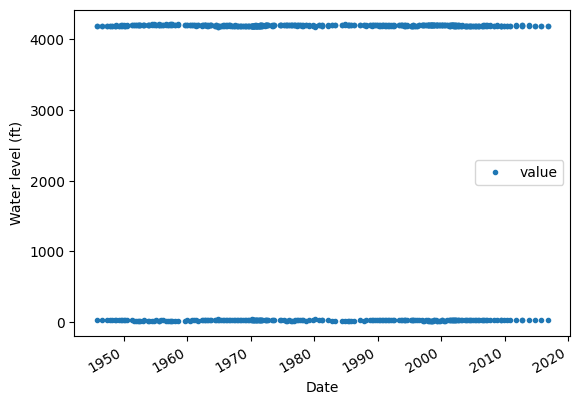

In [7]:
# This site reports several quantities (depth below land surface as well as
# water-surface elevations above NGVD29/NAVD88), so use a datum-neutral label.
ax = data[0][["time", "value"]].plot(x="time", y="value", style=".")
ax.set_xlabel("Date")
ax.set_ylabel("Water level (ft)")

The other part of the result returned from the `get_field_measurements()` function is a metadata object that contains information about the query that was executed to return the data. For example, you can access the URL that was assembled to retrieve the requested data from the USGS Water Data API.

In [8]:
print("The query URL used to retrieve the data from the Water Data API was: " + data[1].url)

The query URL used to retrieve the data from the Water Data API was: https://api.waterdata.usgs.gov/ogcapi/v0/collections/field-measurements/items?monitoring_location_id=USGS-434400121275801&skipGeometry=false&limit=50000


### Additional Examples

You can also request data for multiple monitoring locations at the same time.

Example 2: Get data for multiple monitoring locations. The monitoring location ids are passed as a list of strings.

In [9]:
site_ids = ["USGS-434400121275801", "USGS-375907091432201"]
data2 = waterdata.get_field_measurements(monitoring_location_id=site_ids)
print("Retrieved " + str(len(data2[0])) + " data values.")
display(data2[0])

Retrieving: field-measurements · 1 page · 933 rows

Retrieved 933 data values.


,geometry,field_measurements_series_id,field_visit_id,parameter_code,monitoring_location_id,observing_procedure_code,observing_procedure,value,unit_of_measure,time,qualifier,vertical_datum,approval_status,measuring_agency,last_modified,control_condition,measurement_rated,field_measurement_id
0,POINT (-121.46711 43.73345),df253a1c-d93c-4c08-ac49-6cbdc309712a,c722cb49-bca8-446f-9b4d-3b152729bb39,62610,USGS-434400121275801,O,"GW level, estim, report, observ",4192.65,ft,1945-10-12 22:35:00+00:00,[Static],NGVD29,Approved,USGS,2026-05-09 02:57:58.983507+00:00,None,None,1c77fe40-58ac-4923-a4db-05f6d0ebb147
1,POINT (-121.46711 43.73345),7e4dd765-b0ea-485b-915c-b89eeb86c83e,c722cb49-bca8-446f-9b4d-3b152729bb39,62611,USGS-434400121275801,O,"GW level, estim, report, observ",4196.67,ft,1945-10-12 22:35:00+00:00,[Static],NAVD88,Approved,USGS,2026-05-09 02:57:58.983507+00:00,None,None,2980c321-aeff-442b-a665-8358a8fc0496
2,POINT (-121.46711 43.73345),f997334d-2dc4-49ff-8fab-2e6d2d7c501e,c722cb49-bca8-446f-9b4d-3b152729bb39,72019,USGS-434400121275801,O,"GW level, estim, report, observ",27.35,ft,1945-10-12 22:35:00+00:00,[Static],Local Assumed Datum,Approved,USGS,2026-05-09 02:57:58.983507+00:00,None,None,46bf0d00-0b47-4e4d-adcf-9ce1073c5cfc
3,POINT (-121.46711 43.73345),7e4dd765-b0ea-485b-915c-b89eeb86c83e,0217fd12-a22a-4f4f-a43c-3b9907e2fcc3,62611,USGS-434400121275801,O,"GW level, estim, report, observ",4194.34,ft,1946-07-12 12:00:00+00:00,[Static],NAVD88,Approved,OR004,2026-05-09 02:57:58.983507+00:00,None,None,92f8aaef-b563-4f7f-9b84-9796e26b2c7f
4,POINT (-121.46711 43.73345),df253a1c-d93c-4c08-ac49-6cbdc309712a,0217fd12-a22a-4f4f-a43c-3b9907e2fcc3,62610,USGS-434400121275801,O,"GW level, estim, report, observ",4190.32,ft,1946-07-12 12:00:00+00:00,[Static],NGVD29,Approved,OR004,2026-05-09 02:57:58.983507+00:00,None,None,ddd35e5d-4815-4f8d-a1d2-29cd1d9bdca3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
928,POINT (-91.72294 37.98615),ca0f3961-1a5e-4961-bf55-fd6ac787c98d,48bfbbaa-5db8-4ba2-9e90-742166552bec,72019,USGS-375907091432201,V,"GW level, calib electric tape",310.46,ft,2020-06-19 16:04:00+00:00,[Static],Local Assumed Datum,Approved,MO005,2026-05-24 03:45:01.382842+00:00,None,None,86a25600-2327-4ded-802e-49da0cda3f0f
929,POINT (-91.72294 37.98615),a2831c0f-120e-4d81-85e0-2a075f3efe93,48bfbbaa-5db8-4ba2-9e90-742166552bec,62610,USGS-375907091432201,V,"GW level, calib electric tape",878.54,ft,2020-06-19 16:04:00+00:00,[Static],NGVD29,Approved,MO005,2026-05-24 03:45:01.382842+00:00,None,None,a4c2a304-dcdd-4dc7-abca-84327b0c9f6b
930,POINT (-91.72294 37.98615),ca0f3961-1a5e-4961-bf55-fd6ac787c98d,68eeb933-ea4d-4e8c-be48-605c06cb36fc,72019,USGS-375907091432201,V,"GW level, calib electric tape",313.48,ft,2020-08-31 13:00:00+00:00,[Static],Local Assumed Datum,Approved,MO005,2026-05-24 03:45:01.382842+00:00,None,None,6b812ee5-8821-44fb-93cc-2884257c99bb
931,POINT (-91.72294 37.98615),4313fc31-8700-42b7-99fd-87076c30d305,68eeb933-ea4d-4e8c-be48-605c06cb36fc,62611,USGS-375907091432201,V,"GW level, calib electric tape",875.66,ft,2020-08-31 13:00:00+00:00,[Static],NAVD88,Approved,MO005,2026-05-24 03:45:01.382842+00:00,None,None,7bbcdb45-2154-4fe3-aee7-c3e2bba2bb9b


The following example requests the same data as the previous example, again passing the monitoring location ids as a list of strings.

In [10]:
site_ids = ["USGS-434400121275801", "USGS-375907091432201"]
data2 = waterdata.get_field_measurements(monitoring_location_id=site_ids, )
print("Retrieved " + str(len(data2[0])) + " data values.")
display(data2[0])

Retrieving: field-measurements · 1 page · 933 rows

Retrieved 933 data values.


,geometry,field_measurements_series_id,field_visit_id,parameter_code,monitoring_location_id,observing_procedure_code,observing_procedure,value,unit_of_measure,time,qualifier,vertical_datum,approval_status,measuring_agency,last_modified,control_condition,measurement_rated,field_measurement_id
0,POINT (-121.46711 43.73345),df253a1c-d93c-4c08-ac49-6cbdc309712a,c722cb49-bca8-446f-9b4d-3b152729bb39,62610,USGS-434400121275801,O,"GW level, estim, report, observ",4192.65,ft,1945-10-12 22:35:00+00:00,[Static],NGVD29,Approved,USGS,2026-05-09 02:57:58.983507+00:00,None,None,1c77fe40-58ac-4923-a4db-05f6d0ebb147
1,POINT (-121.46711 43.73345),7e4dd765-b0ea-485b-915c-b89eeb86c83e,c722cb49-bca8-446f-9b4d-3b152729bb39,62611,USGS-434400121275801,O,"GW level, estim, report, observ",4196.67,ft,1945-10-12 22:35:00+00:00,[Static],NAVD88,Approved,USGS,2026-05-09 02:57:58.983507+00:00,None,None,2980c321-aeff-442b-a665-8358a8fc0496
2,POINT (-121.46711 43.73345),f997334d-2dc4-49ff-8fab-2e6d2d7c501e,c722cb49-bca8-446f-9b4d-3b152729bb39,72019,USGS-434400121275801,O,"GW level, estim, report, observ",27.35,ft,1945-10-12 22:35:00+00:00,[Static],Local Assumed Datum,Approved,USGS,2026-05-09 02:57:58.983507+00:00,None,None,46bf0d00-0b47-4e4d-adcf-9ce1073c5cfc
3,POINT (-121.46711 43.73345),7e4dd765-b0ea-485b-915c-b89eeb86c83e,0217fd12-a22a-4f4f-a43c-3b9907e2fcc3,62611,USGS-434400121275801,O,"GW level, estim, report, observ",4194.34,ft,1946-07-12 12:00:00+00:00,[Static],NAVD88,Approved,OR004,2026-05-09 02:57:58.983507+00:00,None,None,92f8aaef-b563-4f7f-9b84-9796e26b2c7f
4,POINT (-121.46711 43.73345),df253a1c-d93c-4c08-ac49-6cbdc309712a,0217fd12-a22a-4f4f-a43c-3b9907e2fcc3,62610,USGS-434400121275801,O,"GW level, estim, report, observ",4190.32,ft,1946-07-12 12:00:00+00:00,[Static],NGVD29,Approved,OR004,2026-05-09 02:57:58.983507+00:00,None,None,ddd35e5d-4815-4f8d-a1d2-29cd1d9bdca3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
928,POINT (-91.72294 37.98615),ca0f3961-1a5e-4961-bf55-fd6ac787c98d,48bfbbaa-5db8-4ba2-9e90-742166552bec,72019,USGS-375907091432201,V,"GW level, calib electric tape",310.46,ft,2020-06-19 16:04:00+00:00,[Static],Local Assumed Datum,Approved,MO005,2026-05-24 03:45:01.382842+00:00,None,None,86a25600-2327-4ded-802e-49da0cda3f0f
929,POINT (-91.72294 37.98615),a2831c0f-120e-4d81-85e0-2a075f3efe93,48bfbbaa-5db8-4ba2-9e90-742166552bec,62610,USGS-375907091432201,V,"GW level, calib electric tape",878.54,ft,2020-06-19 16:04:00+00:00,[Static],NGVD29,Approved,MO005,2026-05-24 03:45:01.382842+00:00,None,None,a4c2a304-dcdd-4dc7-abca-84327b0c9f6b
930,POINT (-91.72294 37.98615),ca0f3961-1a5e-4961-bf55-fd6ac787c98d,68eeb933-ea4d-4e8c-be48-605c06cb36fc,72019,USGS-375907091432201,V,"GW level, calib electric tape",313.48,ft,2020-08-31 13:00:00+00:00,[Static],Local Assumed Datum,Approved,MO005,2026-05-24 03:45:01.382842+00:00,None,None,6b812ee5-8821-44fb-93cc-2884257c99bb
931,POINT (-91.72294 37.98615),4313fc31-8700-42b7-99fd-87076c30d305,68eeb933-ea4d-4e8c-be48-605c06cb36fc,62611,USGS-375907091432201,V,"GW level, calib electric tape",875.66,ft,2020-08-31 13:00:00+00:00,[Static],NAVD88,Approved,MO005,2026-05-24 03:45:01.382842+00:00,None,None,7bbcdb45-2154-4fe3-aee7-c3e2bba2bb9b


Some groundwater level data have dates that include only a year or a month and year, but no day.

Example 3: Retrieve groundwater level data that have dates without a day.

In [11]:
data3 = waterdata.get_field_measurements(monitoring_location_id="USGS-425957088141001")
print("Retrieved " + str(len(data3[0])) + " data values.")

# Observation dates live in the 'time' column (the data frame uses a plain
# integer index). Where the original record gave only a year or a year and
# month, the Water Data API normalizes the value to a UTC timestamp with the
# missing day/time defaulted, so these appear as ordinary timestamps.
print(data3[0]["time"].head(10))

Retrieving: field-measurements · 1 page · 102 rows

Retrieved 102 data values.
0   1945-12-01 12:00:00+00:00
1   1945-12-01 12:00:00+00:00
2   1945-12-01 12:00:00+00:00
3   1946-12-01 12:00:00+00:00
4   1946-12-01 12:00:00+00:00
5   1946-12-01 12:00:00+00:00
6   1947-01-01 12:00:00+00:00
7   1947-01-01 12:00:00+00:00
8   1947-01-01 12:00:00+00:00
9   1948-01-01 12:00:00+00:00
Name: time, dtype: datetime64[us, UTC]


If you want to inspect the request that was sent, you can get the URL for the query that was issued to the USGS Water Data API.

In [12]:
# Print the URL used to retrieve the data
print("You can examine the data retrieved from the Water Data API at: " + data3[1].url)

You can examine the data retrieved from the Water Data API at: https://api.waterdata.usgs.gov/ogcapi/v0/collections/field-measurements/items?monitoring_location_id=USGS-425957088141001&skipGeometry=false&limit=50000


You can also retrieve data for a monitoring location within a specified time window by giving a start and end date.

Example 4: Get groundwater level data for a monitoring location between a start and end date.

In [13]:
data4 = waterdata.get_field_measurements(monitoring_location_id=site_id, time="1980-01-01/2000-12-31")
print("Retrieved " + str(len(data4[0])) + " data values.")

Retrieving: field-measurements · 1 page · 213 rows

Retrieved 213 data values.
